<h1>Import Libraries</h1>



In [ ]:
# Install required packages if not available
import sys
!{sys.executable} -m pip install kagglehub pandas numpy matplotlib seaborn plotly

print("Packages installed successfully!")

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

# Recommendation system libraries
from scipy.sparse import csr_matrix

# Install implicit if not available
import subprocess
import sys

print("Checking for implicit library...")
try:
    import implicit
    print(" implicit library is already available")
except ImportError:
    print(" implicit library not found. Installing...")
    try:
        # Try installing with pip
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'implicit'])
        print(" implicit library installed via pip")
        
        # Try importing again
        import implicit
        print(" implicit library imported successfully")
        
    except Exception as e:
        print(f" Installation failed: {e}")
        print(" Please try manually installing with: pip install implicit")
        print(" Or try: conda install -c conda-forge implicit")
        raise ImportError("Could not install implicit library")


Packages installed successfully!
Libraries imported successfully!
Checking for implicit library...
 implicit library is already available


<h1>Load the Data</h1>
<p>Takes about 1 minute</p>

In [ ]:
# Load existing train/validation split files (FAST VERSION)
def load_existing_split(output_dir='./data_splits/'):
    """
    Load previously created train/validation split files
    Use this instead of recreating the split to save time
    """
    import os
    
    train_file = os.path.join(output_dir, 'train_data.csv')
    val_file = os.path.join(output_dir, 'validation_data.csv')
    
    print(" Loading existing train/validation split files...")
    
    # Check if files exist
    if not os.path.exists(train_file):
        print(f" Train file not found: {train_file}")
        print(" You need to run the split creation cell first!")
        return None, None
    
    if not os.path.exists(val_file):
        print(f" Validation file not found: {val_file}")
        print(" You need to run the split creation cell first!")
        return None, None
    
    # Load the files
    print(f" Loading train data from: {train_file}")
    df_train = pd.read_csv(train_file)
    
    print(f" Loading validation data from: {val_file}")
    df_validation = pd.read_csv(val_file)
    
    # Display info about loaded data
    print(f"\n Successfully loaded existing split:")
    print(f"   Train set: {len(df_train):,} interactions from {df_train['user_id'].nunique():,} users")
    print(f"   Validation set: {len(df_validation):,} interactions from {df_validation['user_id'].nunique():,} users")
    print(f"   Train tracks: {df_train['trackname'].nunique():,} unique tracks")
    print(f"   Validation tracks: {df_validation['trackname'].nunique():,} unique tracks")
    
    # Check data integrity
    common_users = set(df_train['user_id'].unique()).intersection(set(df_validation['user_id'].unique()))
    print(f"   Users in both sets: {len(common_users):,} (this is normal)")
    
    return df_train, df_validation

#  Load existing split 
print(" LOADING EXISTING TRAIN/VALIDATION SPLIT")
print("="*50)

df_train, df_validation = load_existing_split()
df = pd.concat([df_train,df_validation])

if df_train is not None and df_validation is not None:
    print(f"\n Ready to proceed with model training and validation!")
    print(f" No need to recreate the split - using existing files for speed")
else:
    print(f"\n  Could not load existing split files")
    print(f" Run the 'Create train/validation split' cell first to generate the files")

 LOADING EXISTING TRAIN/VALIDATION SPLIT
 Loading existing train/validation split files...
 Loading train data from: ./data_splits/train_data.csv
 Loading validation data from: ./data_splits/validation_data.csv

 Successfully loaded existing split:
   Train set: 10,226,828 interactions from 15,910 users
   Validation set: 2,247,978 interactions from 15,518 users
   Train tracks: 2,250,904 unique tracks
   Validation tracks: 665,365 unique tracks
   Users in both sets: 15,518 (this is normal)

 Ready to proceed with model training and validation!
 No need to recreate the split - using existing files for speed


<h1>Visualize the data </h1>

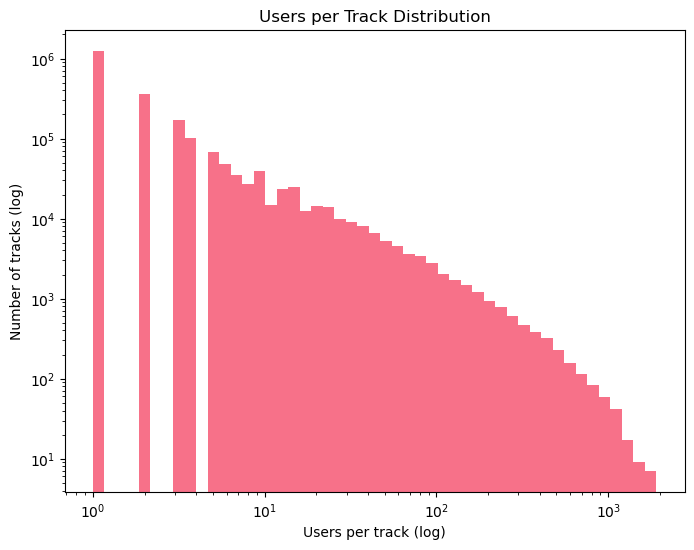

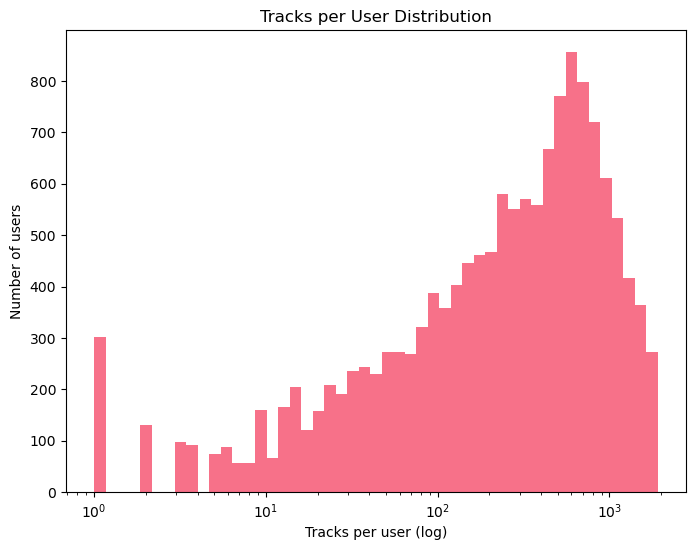

In [4]:
# users_per_track

users_per_track = (
    df.groupby("trackname")["user_id"]
      .nunique()
      .values
)

users_per_track = np.array(users_per_track)

bins = np.logspace(
    np.log10(users_per_track.min()),
    np.log10(users_per_track.max()),
    50
)

plt.figure(figsize=(8, 6))
plt.hist(users_per_track, bins=bins)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Users per track (log)')
plt.ylabel('Number of tracks (log)')
plt.title('Users per Track Distribution')
plt.show()

# tracks_per_user
tracks_per_user = (
    df.groupby("user_id")["trackname"]
      .nunique()
      .values
)

plt.figure(figsize=(8, 6))
plt.hist(tracks_per_user, bins=bins)
plt.xscale("log")
plt.xlabel("Tracks per user (log)")
plt.ylabel("Number of users")
plt.title("Tracks per User Distribution")
plt.show()

<h1>Preprocessing</h1>

In [ ]:
# Filter out users and items with insufficient interactions. Takes > 1 minute

def filter_low_signal(df, min_tracks=5, min_users=5):
    """
    Applied to the FULL dataset to ensure every user/item in the 
    validation set also exists in the training set with sufficient signal.
    """
    print(f"Starting total records: {len(df):,}")
    
    # Iterative filtering to ensure both conditions are met
    while True:
        starting_size = len(df)
        df = df.groupby('trackname').filter(lambda x: len(x) >= min_users)
        df = df.groupby('user_id').filter(lambda x: len(x) >= min_tracks)
        if len(df) == starting_size:
            break
            
    print(f"Filtered total records: {len(df):,}")
    return df

df_train = filter_low_signal(df_train, min_tracks=5, min_users=5)
df_validation = filter_low_signal(df_validation, min_tracks=5, min_users=5)    

Starting total records: 10,226,828
Filtered total records: 7,309,402
Starting total records: 2,247,978
Filtered total records: 1,334,980


In [ ]:
from implicit.nearest_neighbours import bm25_weight

def build_training_matrix(df_train):
    """
    Creates the weighted matrix for the ALS model to learn from.
    """
    # 1. Aggregate and Log Scale
    counts = df_train.groupby(['user_id', 'trackname']).size().reset_index(name='c')
    counts['w'] = np.log1p(counts['c'])
    
    # 2. Map to Categorical (Crucial for matrix indexing)
    counts['user_id'] = counts['user_id'].astype('category')
    counts['trackname'] = counts['trackname'].astype('category')
    
    # 3. Create Sparse Matrix
    train_matrix = csr_matrix(
        (counts['w'].astype(np.float32), 
        (counts['user_id'].cat.codes, counts['trackname'].cat.codes))
    )
    
    # 4. Apply BM25 Weighting
    # This happens ONLY on training data
    weighted_train = bm25_weight(train_matrix, K1=1.2, B=0.75).tocsr()
    
    # Keep these to align the validation set later
    user_categories = counts['user_id'].cat.categories
    track_categories = counts['trackname'].cat.categories
    
    return weighted_train, user_categories, track_categories

train_processed, u_cat, t_cat = build_training_matrix(df_train)
print("Training matrix built successfully!")


Training matrix built successfully!


In [8]:
# optionally apply logic to boost weights based on Artist Affinity
# this did not seem to improve the results   

"""

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from implicit.nearest_neighbours import bm25_weight

def build_artist_boosted_matrix(df_train, boost_factor=0.5):
    
    #Creates a User-Item matrix where weights are boosted by Artist Affinity.
    
    print("Step 1: Calculating Track-Artist mapping...")
    # Group interactions by User and Track
    interactions = df_train.groupby(['user_id', 'trackname', 'artistname']).size().reset_index(name='count')
    
    print("Step 2: Calculating User-Artist affinity...")
    # How many tracks by this artist does the user have?
    user_artist_counts = df_train.groupby(['user_id', 'artistname']).size().reset_index(name='artist_count')
    
    # Merge artist affinity back into interaction data
    interactions = interactions.merge(user_artist_counts, on=['user_id', 'artistname'], how='left')
    
    print("Step 3: Applying Artist Boost...")
    # Log scaling original counts
    interactions['log_count'] = np.log1p(interactions['count'])
    
    # Apply Boost: 1.0 (baseline) + (Artist Count scaled)
    # We log scale the artist count so a user with 100 songs by an artist 
    # doesn't completely drown out a user with 5.
    interactions['boosted_weight'] = interactions['log_count'] * (1 + (boost_factor * np.log1p(interactions['artist_count'])))
    
    print("Step 4: Building Sparse Matrix...")
    # Map to categories for integer indexing
    interactions['user_id'] = interactions['user_id'].astype('category')
    interactions['trackname'] = interactions['trackname'].astype('category')
    
    u_cat = interactions['user_id'].cat.categories
    t_cat = interactions['trackname'].cat.categories
    
    matrix = csr_matrix(
        (interactions['boosted_weight'].astype(np.float32), 
        (interactions['user_id'].cat.codes, interactions['trackname'].cat.codes))
    )
    
    # Apply BM25 on top of the boosted weights
    print("Step 5: Final BM25 weighting...")
    final_matrix = bm25_weight(matrix, K1=1.5, B=0.75).tocsr()
    
    return final_matrix, u_cat, t_cat

# Execute
train_processed, u_cat, t_cat = build_artist_boosted_matrix(df_train)

"""

'\n\nimport numpy as np\nimport pandas as pd\nfrom scipy.sparse import csr_matrix\nfrom implicit.nearest_neighbours import bm25_weight\n\ndef build_artist_boosted_matrix(df_train, boost_factor=0.5):\n    \n    #Creates a User-Item matrix where weights are boosted by Artist Affinity.\n    \n    print("Step 1: Calculating Track-Artist mapping...")\n    # Group interactions by User and Track\n    interactions = df_train.groupby([\'user_id\', \'trackname\', \'artistname\']).size().reset_index(name=\'count\')\n    \n    print("Step 2: Calculating User-Artist affinity...")\n    # How many tracks by this artist does the user have?\n    user_artist_counts = df_train.groupby([\'user_id\', \'artistname\']).size().reset_index(name=\'artist_count\')\n    \n    # Merge artist affinity back into interaction data\n    interactions = interactions.merge(user_artist_counts, on=[\'user_id\', \'artistname\'], how=\'left\')\n    \n    print("Step 3: Applying Artist Boost...")\n    # Log scaling original co

In [9]:
def build_validation_matrix(df_val, user_categories, track_categories):
    """
    Creates a binary/raw matrix for validation. 
    Matches IDs to the training matrix.
    """
    # Map validation IDs to the training category codes
    # Any item in Val NOT in Train will be dropped (NaN)
    user_map = {name: i for i, name in enumerate(user_categories)}
    track_map = {name: i for i, name in enumerate(track_categories)}
    
    df_val['u_idx'] = df_val['user_id'].map(user_map)
    df_val['t_idx'] = df_val['trackname'].map(track_map)
    
    # Drop records that couldn't be mapped (if any)
    df_val = df_val.dropna(subset=['u_idx', 't_idx'])
    
    val_matrix = csr_matrix(
        (np.ones(len(df_val), dtype=np.float32), 
        (df_val['u_idx'].astype(int), df_val['t_idx'].astype(int))),
        shape=(len(user_categories), len(track_categories))
    )
    
    return val_matrix

validation = build_validation_matrix(df_validation, u_cat, t_cat)
print("Validation matrix built successfully!")

Validation matrix built successfully!


<h1>Build the Model</h1>

In [10]:
import random
from implicit.evaluation import AUC_at_k

# Initialize the ALS model
model = implicit.als.AlternatingLeastSquares(
    factors=100, 
    regularization=0.01, 
    iterations=15,
    random_state=42
)

print(f"Training matrix shape: {train_processed.shape} (users x items)")

model.fit(train_processed) 

print(f" Model trained successfully!")
print(f"Model user factors: {model.user_factors.shape[0]} users")
print(f"Model item factors: {model.item_factors.shape[0]} items")

c:\Users\mstan\anaconda3\Lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: Intel MKL BLAS is configured to use 6 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'MKL_NUM_THREADS=1' or by callng 'threadpoolctl.threadpool_limits(1, "blas")'. Having MKL use a threadpool can lead to severe performance issues
  check_blas_config()


Training matrix shape: (14878, 354258) (users x items)


  0%|          | 0/15 [00:00<?, ?it/s]

 Model trained successfully!
Model user factors: 14878 users
Model item factors: 354258 items


<h1>Initial Model Evaluation</hq>

In [ ]:
import time

def evaluate_recommender(model, train_matrix, val_matrix, n_samples=1000):
    """
    Model evaluation:
    1. AUC_at_k for global ranking performance.
    2. MPR with training-item masking for discovery performance.
    """
    print(f"Starting Evaluation (Users: {train_matrix.shape[0]}, Items: {train_matrix.shape[1]})")
    
    # --- 1. AUC ---
    # Transpose train_matrix because AUC_at_k expects [Items x Users]
    start_auc = time.time()
    auc_score = AUC_at_k(model, train_matrix.T, val_matrix, K=100)
    print(f" AUC calculation complete ({time.time() - start_auc:.2f}s)")

    # --- 2. MEAN PERCENTILE RANK (MPR) ---
    print(f"Calculating MPR (Sampling {n_samples} users)...")
    
    # Find all users who have data in the validation set
    val_user_indices = np.unique(val_matrix.nonzero()[0])
    
    # Filter out users who might be outside the model's factor range
    val_user_indices = val_user_indices[val_user_indices < model.user_factors.shape[0]]
    
    # Randomly sample to keep computation efficient
    if len(val_user_indices) > n_samples:
        sample_users = np.random.choice(val_user_indices, size=n_samples, replace=False)
    else:
        sample_users = val_user_indices

    ranking_scores = []
    num_items = train_matrix.shape[1]

    for user_id in sample_users:
        # Get items the user has in validation (the "answers")
        actual_liked_val = val_matrix[user_id].indices
        if len(actual_liked_val) == 0:
            continue
            
        # Get items the user ALREADY had in training (to mask them)
        already_liked_train = train_matrix[user_id].indices
        
        # Calculate raw scores for ALL items for this user
        # Dot product: (1 x Factors) * (Factors x Items) = (1 x Items)
        user_vec = model.user_factors[user_id]
        all_scores = user_vec @ model.item_factors.T
        
        # IMPORTANT: Mask training items by setting their score to -infinity
        # This ensures we are measuring the rank among NEW songs only.
        all_scores[already_liked_train] = -np.inf
        
        for track_id in actual_liked_val:
            if track_id >= num_items:
                continue
                
            test_score = all_scores[track_id]
            
            # Rank = how many items have a higher score than our validation track
            # Lower rank is better (0 = #1 recommendation)
            rank = np.sum(all_scores > test_score)
            
            # Percentile Rank (0.0 to 1.0)
            percentile_rank = rank / num_items
            ranking_scores.append(percentile_rank)

    mpr_score = np.mean(ranking_scores) if ranking_scores else 1.0
    
    print(f" MPR calculation complete.")
    return auc_score, mpr_score

print("\n" + "="*40)
print(" RUNNING EVALUATION")
print("="*40)

try:
    auc, mpr = evaluate_recommender(model, train_processed, validation)
    
    print("\n" + " FINAL METRICS")
    print("-" * 20)
    print(f"AUC Score: {auc:.4f}")
    print(f"MPR Score: {mpr:.4f}")
    print("-" * 20)
    
    # Summary Analysis
    if auc < 0.6 and mpr < 0.01:
        print("\n ANALYSIS: The model is likely suffering from 'Popularity Bias'.")
        print("Model is very good at ranking hits (low MPR), but struggles to distinguish")
        print("between personalized niche tracks (low AUC).")
    elif auc > 0.7:
        print("\n ANALYSIS: The model has strong personalization!")
        
except Exception as e:
    print(f"Error during evaluation: {e}")


 RUNNING EVALUATION
Starting Evaluation (Users: 14878, Items: 354258)


  0%|          | 0/13319 [00:00<?, ?it/s]

 AUC calculation complete (24.84s)
Calculating MPR (Sampling 1000 users)...
 MPR calculation complete.

 FINAL METRICS
--------------------
AUC Score: 0.5813
MPR Score: 0.2704
--------------------


<h1>Hyperparameter Tuning </h1>
Takes about 30 min

In [ ]:
results = []
for f in [100, 200, 400]:
    for r in [0.01, 0.1]:
        print(f"Testing: Factors={f}, Reg={r}")
        
        test_model = implicit.als.AlternatingLeastSquares(
            factors=f, 
            regularization=r, 
            iterations=20, # Increased iterations for better convergence
            random_state=42
        )
        
        test_model.fit(train_processed) 
        
        auc, mpr = evaluate_recommender(test_model, train_processed, validation, n_samples=500)
        results.append({'factors': f, 'reg': r, 'auc': auc, 'mpr': mpr})

# Display results 
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='auc', ascending=False))

Testing: Factors=100, Reg=0.01


  0%|          | 0/20 [00:00<?, ?it/s]

Starting Evaluation (Users: 14878, Items: 354258)


  0%|          | 0/13319 [00:00<?, ?it/s]

 AUC calculation complete (22.73s)
Calculating MPR (Sampling 500 users)...
 MPR calculation complete.
Testing: Factors=100, Reg=0.1


...

 AUC calculation complete (66.47s)
Calculating MPR (Sampling 500 users)...
 MPR calculation complete.
Testing: Factors=400, Reg=0.1


  0%|          | 0/20 [00:00<?, ?it/s]

Starting Evaluation (Users: 14878, Items: 354258)


  0%|          | 0/13319 [00:00<?, ?it/s]

 AUC calculation complete (65.18s)
Calculating MPR (Sampling 500 users)...
 MPR calculation complete.
   factors   reg       auc       mpr
5      400  0.10  0.606570  0.242936
4      400  0.01  0.606564  0.269754
3      200  0.10  0.596790  0.236166
2      200  0.01  0.596788  0.246767
0      100  0.01  0.581283  0.243181
1      100  0.10  0.581269  0.248801


<h1> Train model on full dataset </h1>
Takes about 5 min

In [15]:
df_filtered = filter_low_signal(df, min_tracks=5, min_users=5)
df_matrix, u_cat, t_cat = build_training_matrix(df_filtered)
model = implicit.als.AlternatingLeastSquares(
    factors=400, 
    regularization=0.1, 
    iterations=20,
    random_state=42
)

print(f"Training matrix shape: {df_matrix.shape} (users x items)")

model.fit(df_matrix) 

print(f" Model trained successfully!")
print(f"Model user factors: {model.user_factors.shape[0]} users")
print(f"Model item factors: {model.item_factors.shape[0]} items")

Starting total records: 12,474,806
Filtered total records: 9,488,707
Training matrix shape: (15051, 431334) (users x items)


  0%|          | 0/20 [00:00<?, ?it/s]

 Model trained successfully!
Model user factors: 15051 users
Model item factors: 431334 items


<h1>Final Model Summary</h1>

In [16]:
def global_recommendation_summary(model, train_matrix, track_map, n_users=1000):
    from collections import Counter
    
    print(f"Sampling {n_users} users to find global trends...")
    global_counts = Counter()
    
    # Sample users
    user_indices = np.random.choice(train_matrix.shape[0], size=n_users, replace=False)
    
    for user_id in user_indices:
        ids, _ = model.recommend(user_id, train_matrix[user_id], N=10)
        global_counts.update(ids)
    
    print("\n--- The 10 Most Recommended Songs Globally ---")
    for i, (track_id, count) in enumerate(global_counts.most_common(10)):
        print(f"{i+1}. {track_map[track_id]} (Recommended to {count/n_users:.1%} of sample)")

global_recommendation_summary(model, df_matrix, t_cat)

Sampling 1000 users to find global trends...

--- The 10 Most Recommended Songs Globally ---
1. avicii - wake me up (Recommended to 2.5% of sample)
2. hozier - take me to church (Recommended to 2.1% of sample)
3. m83 - midnight city (Recommended to 2.1% of sample)
4. imagine dragons - radioactive (Recommended to 1.9% of sample)
5. passenger - let her go (Recommended to 1.8% of sample)
6. mark ronson - uptown funk (Recommended to 1.8% of sample)
7. onerepublic - counting stars (Recommended to 1.8% of sample)
8. clean bandit - rather be (Recommended to 1.8% of sample)
9. meghan trainor - all about that bass (Recommended to 1.7% of sample)
10. daft punk - get lucky - radio edit (Recommended to 1.6% of sample)


In [18]:
def model_strength_summary(model):
    # Calculate the average 'length' of the vectors
    user_norms = np.linalg.norm(model.user_factors, axis=1)
    item_norms = np.linalg.norm(model.item_factors, axis=1)
    
    print("--- Model Strength Summary ---")
    print(f"Average User Vector Magnitude: {np.mean(user_norms):.4f}")
    print(f"Average Item Vector Magnitude: {np.mean(item_norms):.4f}")
    print(f"Total Latent Factors: {model.factors}")

model_strength_summary(model)

--- Model Strength Summary ---
Average User Vector Magnitude: 1.4930
Average Item Vector Magnitude: 0.3270
Total Latent Factors: 400


In [19]:
def explain_random_recommendations(model, train_matrix, track_map, n_users=5):
    print(f"--- Explaining Recommendations for {n_users} Random Users ---")
    
    user_indices = np.random.choice(train_matrix.shape[0], size=n_users, replace=False)
    
    for user_id in user_indices:
        # 1. Get the top recommendation for this user
        ids, scores = model.recommend(user_id, train_matrix[user_id], N=1)
        if len(ids) == 0: continue
        
        rec_id = ids[0]
        rec_name = track_map[rec_id]
        
        # 2. Explain WHY that specific song was recommended
        total_score, top_contributions, _ = model.explain(user_id, train_matrix, itemid=rec_id)
        
        print(f"\nUser {user_id} Recommendation: '{rec_name}' (Total Score: {total_score:.3f})")
        print("Because you liked these songs in your history:")
        for track_idx, score in top_contributions[:3]: # Show top 3 contributors
            print(f"   - {track_map[track_idx]} (Contribution: {score:.3f})")
        print("-" * 30)

explain_random_recommendations(model, df_matrix, t_cat)

--- Explaining Recommendations for 5 Random Users ---

User 11091 Recommendation: 'the war on drugs - an ocean in between the waves' (Total Score: 0.968)
Because you liked these songs in your history:
   - future islands - a dream of you and me (Contribution: 0.011)
   - future islands - back in the tall grass (Contribution: 0.011)
   - future islands - light house (Contribution: 0.011)
------------------------------

User 12270 Recommendation: 'coldplay - yellow' (Total Score: 0.728)
Because you liked these songs in your history:
   - coldplay - the scientist (Contribution: 0.050)
   - coldplay - clocks (Contribution: 0.047)
   - coldplay - viva la vida (Contribution: 0.038)
------------------------------

User 14658 Recommendation: 'florence + the machine - youve got the love' (Total Score: 0.927)
Because you liked these songs in your history:
   - florence + the machine - rabbit heart (Contribution: 0.024)
   - florence + the machine - drumming song (Contribution: 0.022)
   - floren